In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], errors='coerce')
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda\envs\cursito\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Find the Optimal Skill to learn for Data Analysts

In [2]:
df_da_us = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [3]:
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

df_da_us_exploded = df_da_us.explode('job_skills')

df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
1681,111175.0,sql
1681,111175.0,tableau
1681,111175.0,power bi
1681,111175.0,excel
3237,120000.0,sql


In [ ]:
# exploded job skills grouped by their salary with new columns count and median
df_da_skills = df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
#rename columns for visualization
df_da_skills = df_da_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})
# length of jobs
df_job_count = len(df_da_us)
# create new column for the percentage
df_da_skills['skill_percent'] = df_da_skills['skill_count'] / df_job_count * 100
#new df that have more than 6% 
df_da_skills_high_demand = df_da_skills[df_da_skills['skill_percent'] > 6]

df_da_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,714,87500.0,63.864043
excel,472,77500.0,42.218247
python,408,90000.0,36.493739
tableau,398,90000.0,35.599284
power bi,279,87500.0,24.955277
r,244,90000.0,21.824687
sas,200,84078.5,17.889088
powerpoint,102,77500.0,9.123435
word,89,75000.0,7.960644


create a new df that contains the category of skills 

In [ ]:
df_technology = df['job_type_skills'].copy()
# remove duplicates
df_technology = df_technology.drop_duplicates()
# remove nan values
df_technology = df_technology.dropna()
#combine al dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict =  ast.literal_eval(row) #convert string into dictionary
    for key, value in row_dict.items():
        if key in technology_dict: #if key already exists then add value to existing
            technology_dict[key] += value
        else:                       #if key doesnt exist add key and value
            technology_dict[key] = value
#remove duplicates by converting values to set then back to list        
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))
    
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,splunk
0,analyst_tools,ssrs
0,analyst_tools,excel
0,analyst_tools,spss
0,analyst_tools,sheets
...,...,...
9,sync,webex
9,sync,wire
9,sync,google chat
9,sync,microsoft teams


In [21]:
df_plot = df_da_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

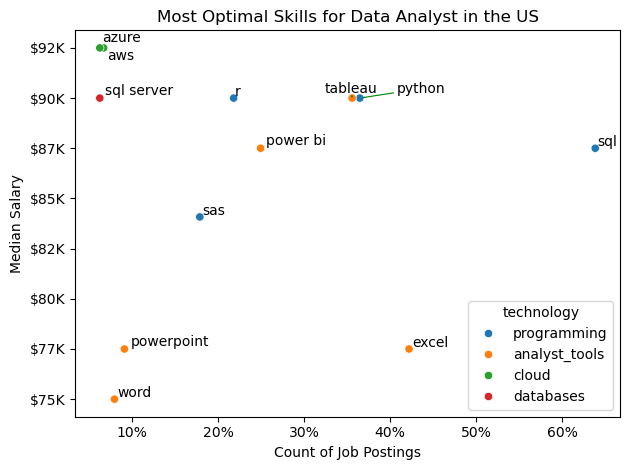

In [ ]:
from matplotlib.patches import ArrowStyle
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

#df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')

sns.scatterplot(
    data = df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
        
# Adjust text to avoid overlap
adjust_text(texts, arrowprops =dict(arrowstyle="->", color='g', lw=0.8))  

# set axis, label, title and legend
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary')
plt.title('Most Optimal Skills for Data Analyst in the US')
# adjust layout and display out
plt.tight_layout()
plt.show()